Starting simulation with Master Seed: 42
Number of Trials: 100
Lambda Grid: [0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]


Simulating Trials:   0%|          | 0/100 [00:00<?, ?it/s]

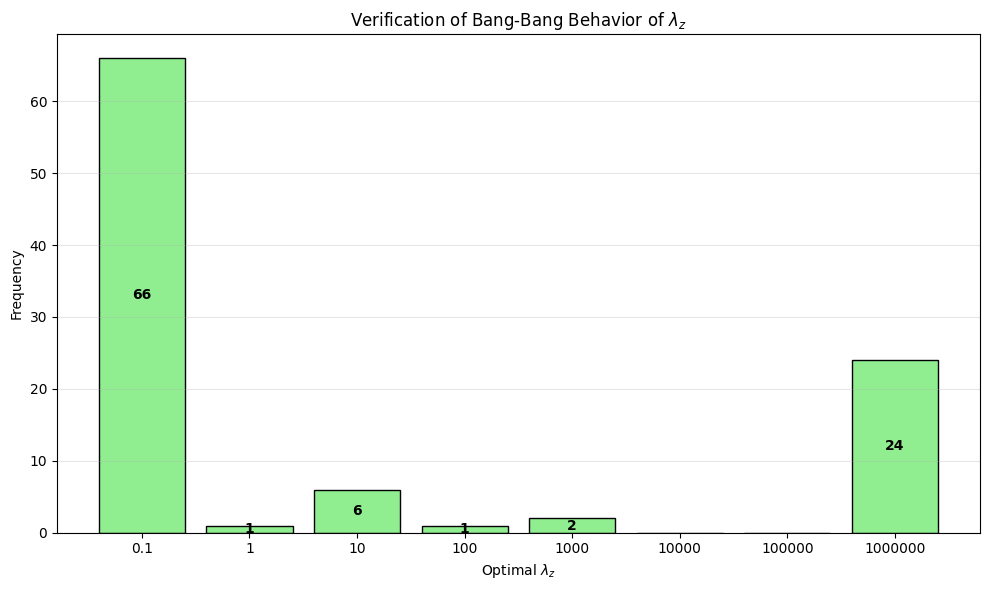

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import expit as sigmoid
from sklearn.linear_model import LogisticRegression
try:
    from tqdm.auto import tqdm
    HAS_TQDM = True
except ImportError:
    HAS_TQDM = False


class BangBangVerifier:
    """
    Simulates and verifies the "Bang-Bang" behavior of optimal regularization parameters
    in the context of learning with side information.
    """
    def __init__(self, d=5, n_primary=4000, m_side=1000, t_oracle=20000, seed=42):
        """
        Initializes the verifier with simulation parameters and data distribution settings.

        Args:
            d (int): Dimensionality of the input features X.
            n_primary (int): Number of samples in the primary dataset (X, Y).
            m_side (int): Number of samples in the side information dataset (X, Z).
            t_oracle (int): Number of samples for population risk estimation.
            seed (int): Random seed for reproducibility.
        """
        self.d = d
        self.n_primary = n_primary
        self.m_side = m_side
        self.t_oracle = t_oracle
        self.seed = seed

        
        self.rng = np.random.RandomState(self.seed)

        # Scale weights to avoid sigmoid saturation
        weight_scale = 1.0 / np.sqrt(d)
        self.u_star = self.rng.randn(d + 1) * weight_scale
        self.w_star = self.rng.randn(d + 2) * weight_scale

        # Initialize Distribution Parameters 
        self.components = self.rng.randint(1, 11)  # Between 1 and 10 components
        self.locs = [self.rng.uniform(-6, 6, size=(self.d, 1)) for _ in range(self.components)]
        self.As = [self.rng.uniform(-2, 2, size=(self.d, self.d)) for _ in range(self.components)]
        self.weights = self.rng.dirichlet(np.ones(self.components)).flatten()

    def _sample_mixture_X(self, samples):
        """
        Samples X from a Gaussian Mixture Model (GMM) with random components.

        Args:
            samples (int): Number of samples to generate.

        Returns:
            np.ndarray: Generated X data of shape (samples, d).
        """
        components = self.rng.choice(self.components, size=samples, p=self.weights)
        X = np.zeros((samples, self.d))
        
        for k in range(self.components):
            idx = np.where(components == k)[0]
            n_k = len(idx)
            if n_k == 0:
                continue
            
            z = self.rng.standard_normal(size=(n_k, self.d))
            # Affine transform: loc + A @ z
            X_k = self.locs[k] + np.matmul(self.As[k], z.T)
            X[idx] = X_k.T
            
        return X

    def _generate_data(self, samples):
        """
        Generates Synthetic Data (X, Y, Z) based on the modeled distributions.

        Args:
            samples (int): Number of samples to generate.

        Returns:
            tuple: (X, Y, Z) where X is features, Y is primary label, Z is side label.
        """
        X = self._sample_mixture_X(samples)

        # Generate Z | X
        X_aug_u = np.hstack([np.ones((samples, 1)), X])
        prob_z = sigmoid(np.dot(X_aug_u, self.u_star))
        Z = 2 * (self.rng.rand(samples) < prob_z) - 1

        # Generate Y | X, Z
        X_aug_w = np.hstack([np.ones((samples, 1)), X, Z.reshape(-1, 1)])
        prob_y = sigmoid(np.dot(X_aug_w, self.w_star))
        Y = 2 * (self.rng.rand(samples) < prob_y) - 1

        return X, Y, Z

    def _loss_function(self, w, X, Z, Y, lambda_c, lambda_x, lambda_z):
        """
        Computes the logistic loss with heterogeneous regularization.

        Args:
            w (np.ndarray): Weight vector [bias, w_x, w_z].
            X (np.ndarray): Feature matrix.
            Z (np.ndarray): Side information vector (actual or imputed).
            Y (np.ndarray): Primary label vector.
            lambda_c (float): Regularization for bias term.
            lambda_x (float): Regularization for feature weights.
            lambda_z (float): Regularization for side information weight.

        Returns:
            float: Total loss (logistic loss + regularization).
        """
        n = X.shape[0]
        X_full = np.hstack([np.ones((n, 1)), X, Z.reshape(-1, 1)])
        scores = np.dot(X_full, w)
        
        # Stable logistic loss: sum(-log(P(Y|X,Z)))
        loss_term = np.sum(-np.log(sigmoid(Y * scores) + 1e-15))
        
        # Regularization: lambda_c * w_0^2 + lambda_x * ||w_x||^2 + lambda_z * w_z^2
        reg_term = (lambda_c * w[0]**2 +
                    lambda_x * np.sum(w[1:-1]**2) +
                    lambda_z * w[-1]**2)
        return loss_term + reg_term

    def find_optimal_lambda(self, lambda_z_grid=[0.1, 1.0, 10.0, 100.0, 1000.0]):
        """
        Identifies the optimal lambda_z from a grid by minimizing population risk.

        Args:
            lambda_z_grid (list): Grid of lambda_z values to sweep over.

        Returns:
            float: The lambda_z that yielded the lowest risk on the population.
        """
        X_d, Y_d, _ = self._generate_data(self.n_primary)
        X_s, _ , Z_s = self._generate_data(self.m_side)
        X_pop, Y_pop, Z_pop = self._generate_data(self.t_oracle)

        # Learn Map X -> Z on S
        phi_model = LogisticRegression(C=1.0, solver='lbfgs', random_state=self.seed)
        
        if len(np.unique(Z_s)) < 2:
            return None

        phi_model.fit(X_s, Z_s)

        # Impute Z on D
        probs_z = phi_model.predict_proba(X_d)[:, 1]
        Z_d_hat = 2.0 * (probs_z >= 0.5) - 1.0

        # Regularization scaling
        lambda_c = 1.0 / np.sqrt(self.n_primary)
        lambda_x = 1.0 / np.sqrt(self.n_primary)

        best_risk = float('inf')
        best_lam = None
        w_init = np.zeros(self.d + 2)

        for lam_z in lambda_z_grid:
            res = minimize(
                fun=self._loss_function,
                x0=w_init,
                args=(X_d, Z_d_hat, Y_d, lambda_c, lambda_x, lam_z),
                method='BFGS'
            )
            w_hat = res.x
            
            # Evaluate on Population
            pop_loss = self._loss_function(w_hat, X_pop, Z_pop, Y_pop, 0, 0, 0)
            pop_risk = pop_loss / self.t_oracle

            if pop_risk < best_risk:
                best_risk = pop_risk
                best_lam = lam_z
        
        return best_lam

def run_simulation(seed=42, lambda_z_grid=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0], n_trials=25):
    """
    Runs the simulation for a specified number of trials.
    Uses tqdm or carriage returns to show progress on a single line.
    """
    print(f"Starting simulation with Master Seed: {seed}")
    print(f"Number of Trials: {n_trials}")
    print(f"Lambda Grid: {lambda_z_grid}")

    rng_master = np.random.RandomState(seed)
    trial_seeds = rng_master.randint(0, 2**30, size=n_trials)
    
    optimal_lambdas = []
    
    if HAS_TQDM:
        pbar = tqdm(total=n_trials, desc="Simulating Trials")
        for trial_seed in trial_seeds:
            verifier = BangBangVerifier(d=5, seed=int(trial_seed))
            best_lam = verifier.find_optimal_lambda(lambda_z_grid=lambda_z_grid)
            if best_lam is not None:
                optimal_lambdas.append(best_lam)
            pbar.update(1)
        pbar.close()
    else:
        for i, trial_seed in enumerate(trial_seeds):
            verifier = BangBangVerifier(d=5, seed=int(trial_seed))
            best_lam = verifier.find_optimal_lambda(lambda_z_grid=lambda_z_grid)
            if best_lam is not None:
                optimal_lambdas.append(best_lam)
            print(f"\rProgress: {i+1}/{n_trials} trials completed.", end="", flush=True)
        print() 

    plt.figure(figsize=(10, 6))
    
    counts = {lam: 0 for lam in lambda_z_grid}
    
    for lam in optimal_lambdas:
        if lam in counts:
            counts[lam] += 1
        else:
            print(f"Warning: Found optimal lambda {lam} not in grid.")

    labels = [str(lam) for lam in lambda_z_grid]
    values = [counts[lam] for lam in lambda_z_grid]
    
    bars = plt.bar(labels, values, color='lightgreen', edgecolor='black')
    
    # Add count labels inside the bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2., height/2.,
                     f'{int(height)}',
                     ha='center', va='center', fontweight='bold')
    
    plt.title(r"Verification of Bang-Bang Behavior of $\lambda_z$")
    plt.xlabel(r"Optimal $\lambda_z$")
    plt.ylabel("Frequency")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_simulation(
        seed=42, 
        lambda_z_grid=[0.1, 1, 10, 100, 1000, 10000, 100000, 1000000], 
        n_trials=100
    )